# **OU Training for Cats**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
import sys, os
sys.path.append(os.getcwd())

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models


## Imports

In [5]:
#%load_ext autoreload
#%autoreload 2

import torch
import numpy as np

from tqdm.auto import trange

from torch.utils.data import DataLoader, Subset
from torch.optim import Adam
import torch
from torch.utils.data import (
    DataLoader,
    Subset,
)
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, Resize, Compose


import sys, os
sys.path.append(os.path.abspath("./"))

import src.diffusion_process as dfp
from src.diffusion_utilities import plot_image_grid
from src.ou_schedules import make_ou_process_functions
from src.score_model import ScoreNet

## Basic configuration

In [6]:
if torch.cuda.is_available():
    device_str = "cuda"
elif torch.backends.mps.is_available():
    device_str = "mps"
else:
    device_str = "cpu"

device = torch.device(device_str)
print("Device:", device)

n_threads = torch.get_num_threads()
print("Number of threads:", n_threads)

_ = torch.manual_seed(123)

Device: cuda
Number of threads: 24


## Load dataset

In [7]:
# Define transformations to apply to the images
transform = Compose([
    Resize((64, 64)),
    ToTensor(),
    Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Dataset AFHQ
data = datasets.ImageFolder(
    root="./data/afhq/train",
    transform=transform
)

# Create a subset dataset composed of only images of cats
cat_idx = data.class_to_idx["cat"]
cat_indices = [i for i, (_, label) in enumerate(data.imgs) if label == cat_idx]
np.random.shuffle(cat_indices)

# Create a Subset dataset using the selected indices
data_train = Subset(data, cat_indices)

# Create a DataLoader for the training dataset
data_loader = DataLoader(
    data_train,
    batch_size=32,
    shuffle=True,
    num_workers=n_threads,
)

print(type(data_train))
print("Number of images:", len(data_train))

<class 'torch.utils.data.dataset.Subset'>
Number of images: 5153


## Dataset visualization

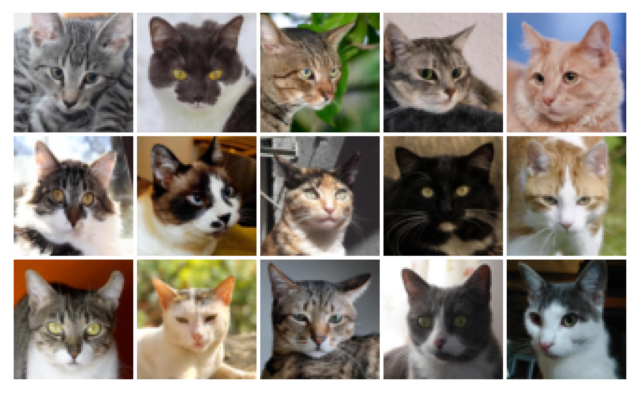

In [8]:
# Visualize training images
n_rows = 3
n_cols = 5

_ = plot_image_grid(
    images=torch.stack([data_train[i][0] for i in range(n_rows * n_cols)]),
    figsize=(8, 8),
    n_rows=n_rows,
    n_cols=n_cols,
)

## Model creation

In [9]:
schedule_name = "cosine"
sched = make_ou_process_functions(schedule_name)

drift_coeff = sched["drift_coefficient"]
diffusion_coeff = sched["diffusion_coefficient"]
mu_t = sched["mu_t"]
sigma_t = sched["sigma_t"]

# Define the Gaussian Diffusion Process
diffusion_process = dfp.GaussianDiffusionProcess(
    drift_coefficient=drift_coeff,
    diffusion_coefficient=diffusion_coeff,
    mu_t=mu_t,
    sigma_t=sigma_t
)

# Define the score model
score_model = ScoreNet(
    marginal_prob_std=sigma_t,
    in_channels=3,
    out_channels=3,
    channels=(64, 128, 256, 512),
    embed_dim=256
).to(device)

## Training

In [ ]:
learning_rate = 1.0e-4
optimizer = Adam(score_model.parameters(), lr=learning_rate)

n_epochs = 1000
tqdm_epoch = trange(n_epochs)

for epoch in tqdm_epoch:
    avg_loss = 0.0
    num_items = 0

    for x, y in data_loader:
        x = x.to(device)

        loss = diffusion_process.loss_function(score_model, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    tqdm_epoch.set_description(
        "Average Loss: {:5f}".format(avg_loss / num_items)
    )

    # Save the model every 50 epochs
    if (epoch + 1) in [10, 20, 50, 100, 200, 500, 1000]:
        path = f"./checkpoints/afhq_ou_{schedule_name}/checkpoint_ou_{schedule_name}_epoch{epoch+1}.pth"
        torch.save(score_model.state_dict(), path)
        print(f"Saved: {path}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Saved: ./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch10.pth
Saved: ./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch20.pth
Saved: ./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch50.pth
Saved: ./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch100.pth
Saved: ./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch200.pth
Saved: ./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch500.pth
Saved: ./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch1000.pth


In [10]:
# Cargar el mejor checkpoint (epoch 100)
start_epoch = 1000
score_model.load_state_dict(torch.load(
    f"./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch{start_epoch}.pth",
    map_location=device
))

# Optimizer con lr reducido
optimizer = Adam(score_model.parameters(), lr=1.0e-5)

# Continuar entrenando
n_epochs_extra = 1000  # llega hasta epoch 2000 absoluta
tqdm_epoch = trange(n_epochs_extra)

for epoch in tqdm_epoch:
    avg_loss = 0.0
    num_items = 0

    for x, y in data_loader:
        x = x.to(device)
        loss = diffusion_process.loss_function(score_model, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    tqdm_epoch.set_description(
        "Average Loss: {:5f}".format(avg_loss / num_items)
    )

    absolute_epoch = start_epoch + epoch + 1
    if absolute_epoch in [1100, 1200, 1500, 2000]:
        path = f"./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch{absolute_epoch}_finetune.pth"
        torch.save(score_model.state_dict(), path)
        print(f"Saved: {path}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Saved: ./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch1100_finetune.pth
Saved: ./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch1200_finetune.pth
Saved: ./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch1500_finetune.pth
Saved: ./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch2000_finetune.pth
